In [1]:
# Deteccion (o emparejamiento de imagenes) por caracteristicas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
cereal = cv2.imread('cereal.png')
cereales = cv2.imread('cereales.png')

In [4]:
cereal = cv2.cvtColor(cereal, cv2.COLOR_BGR2RGB)
cereales = cv2.cvtColor(cereales, cv2.COLOR_BGR2RGB)

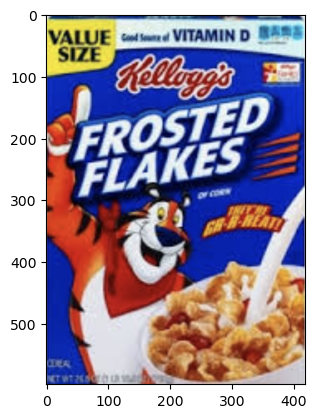

In [5]:
plt.imshow(cereal)

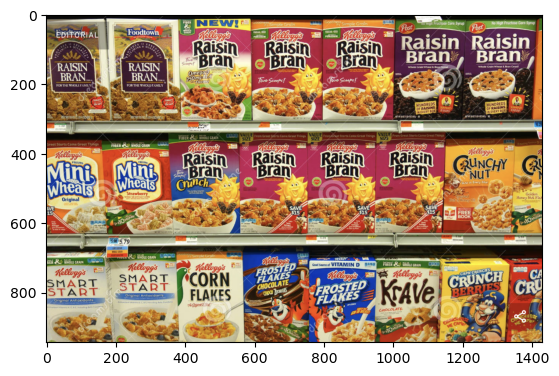

In [6]:
plt.imshow(cereales)

In [8]:
print(cv2.__version__)

4.12.0


In [10]:
# sift = cv2.xfeatures2d.SIFT_create() <-- es para versiones anteriores de openCV
sift = cv2.SIFT_create()

In [11]:
kp1, des1 = sift.detectAndCompute(cereal, None)
kp2, des2 = sift.detectAndCompute(cereales, None)

In [12]:
des1

array([[23.,  5.,  4., ...,  0.,  0.,  3.],
       [ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  1.],
       ...,
       [ 0., 46., 10., ...,  1.,  0.,  3.],
       [ 5.,  1.,  3., ..., 86., 33.,  2.],
       [ 0.,  0.,  0., ...,  0.,  1.,  9.]], dtype=float32)

In [13]:
des2

array([[ 2.,  1.,  0., ..., 13.,  7.,  4.],
       [47., 46.,  5., ...,  0.,  0.,  0.],
       [ 4.,  6., 10., ...,  0.,  0.,  0.],
       ...,
       [13., 12.,  0., ...,  0., 32., 39.],
       [ 1.,  0.,  0., ...,  3.,  1., 18.],
       [23., 73., 49., ...,  2.,  0.,  7.]], dtype=float32)

In [14]:
indice = dict(algorithm=0, trees=5)

In [15]:
indice

{'algorithm': 0, 'trees': 5}

In [16]:
busqueda = dict(checks=50)

In [17]:
busqueda

{'checks': 50}

In [18]:
flan = cv2.FlannBasedMatcher(indice, busqueda)

In [20]:
emparejamientos = flan.knnMatch(des1, des2, k=2)

In [21]:
emparejamientos

((< cv2.DMatch 0000028849898FD0>, < cv2.DMatch 00000288498B6270>),
 (< cv2.DMatch 00000288498B6230>, < cv2.DMatch 00000288498B6290>),
 (< cv2.DMatch 00000288498B6310>, < cv2.DMatch 00000288498B62D0>),
 (< cv2.DMatch 00000288498B5EF0>, < cv2.DMatch 00000288498B6210>),
 (< cv2.DMatch 00000288498B5690>, < cv2.DMatch 00000288498B5B70>),
 (< cv2.DMatch 00000288498B5630>, < cv2.DMatch 00000288498B5890>),
 (< cv2.DMatch 00000288498B61B0>, < cv2.DMatch 00000288498B61D0>),
 (< cv2.DMatch 00000288498B6330>, < cv2.DMatch 00000288498B6110>),
 (< cv2.DMatch 00000288498B6350>, < cv2.DMatch 00000288498B6370>),
 (< cv2.DMatch 00000288498B6390>, < cv2.DMatch 00000288498B63B0>),
 (< cv2.DMatch 00000288498B63D0>, < cv2.DMatch 00000288498B63F0>),
 (< cv2.DMatch 00000288498B6410>, < cv2.DMatch 00000288498B6430>),
 (< cv2.DMatch 00000288498B6450>, < cv2.DMatch 00000288498B6470>),
 (< cv2.DMatch 00000288498B6490>, < cv2.DMatch 00000288498B64B0>),
 (< cv2.DMatch 00000288498B64D0>, < cv2.DMatch 00000288498B64F

In [22]:
mejores = []
for e1, e2 in emparejamientos:
    if e1.distance < 0.7*e2.distance:
        mejores.append([e1])

In [24]:
e1.distance

285.9510498046875

In [25]:
e2.distance

296.6934509277344

In [26]:
imagen_emparejamientos = cv2.drawMatchesKnn(cereal, kp1, cereales, kp2, mejores[0:30], None, flags=0)

In [27]:
imagen_emparejamientos = cv2.cvtColor(imagen_emparejamientos, cv2.COLOR_BGR2RGB)

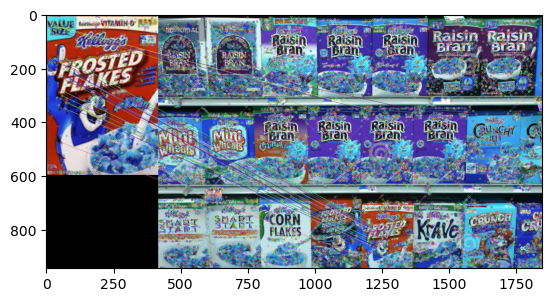

In [29]:
plt.imshow(imagen_emparejamientos)

In [ ]:
figura = plt.figure(figsize